In [1]:
# Enhanced Stacking Meta-Learner
# 
# It does **not** retrain BERT, RoBERTa, GRU, or TF-IDF/SVM. It loads your saved base models, generates or loads cached probabilities, 
# and then evaluates the meta-learning stage.
# 
# This version produces:
# - the **final selected XGBoost stacking classification report** on the frozen held-out test set,
# - the **final selected XGBoost confusion matrix** as printed values, CSV, and PNG,
# - an **XGBoost-only ablation study table** 
# - the **final Logistic Regression stacking classification report** for comparison,
# - saved CSV artifacts for reports, predictions, confusion matrix, and ablation results.

# CONFIGURATION

SEED = 42

# Data and saved base-model paths
DATA_PATH = "combineddataset.xls"
TEXT_COL = "Base_Reviews"
LABEL_COL = "category"

GRU_MODEL_PATH = "./final_gru_10class_cv.h5"
GRU_TOKENIZER_PATH = "./final_gru_tokenizer_cv.pkl"

BERT_DIR = "./bert_best"
ROBERTA_DIR = "./roberta_best"

SVM_MODEL_PATH = "tfidf_svm_final.pkl"
TFIDF_PATH = "tfidf_vectorizer_final.pkl"

CACHE_DIR = "./stack_cache_no_retrain"
CACHE_FILE = f"{CACHE_DIR}/base_probs_trainval_test.npz"

TRANSFORMER_MAX_LEN = 128

# GRU max length
GRU_MAX_LEN = 100

# Inference batch sizes
BERT_BATCH_SIZE = 8
ROBERTA_BATCH_SIZE = 6

# Class order used by all base models
your_class_order = [
    "self-direction", "stimulation", "hedonism", "achievement", "power",
    "security", "conformity", "tradition", "benevolence", "universalism"
]
n_classes = len(your_class_order)
y_dict = {label: idx for idx, label in enumerate(your_class_order)}
idx_to_label = {idx: label for label, idx in y_dict.items()}

# Force TensorFlow GRU inference on CPU to avoid TF/PyTorch GPU conflict.
FORCE_TF_CPU = True

# If cache exists, use cached base probabilities to avoid recomputing base predictions.
USE_CACHE_IF_AVAILABLE = True

# IMPORTS AND UTILS
import os
import re
import gc
import json
import pickle
import joblib
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(SEED)

# Basic ML
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# XGBoost
from xgboost import XGBClassifier

# Plotting
import matplotlib.pyplot as plt

# NLTK + safe fallback
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet as wn

try:
    from nltk.tokenize import word_tokenize
    from nltk import pos_tag
except Exception:
    word_tokenize = None
    pos_tag = None

try:
    nltk.download("punkt", quiet=True)
    nltk.download("averaged_perceptron_tagger", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("stopwords", quiet=True)
except Exception:
    pass

try:
    STOP_WORDS = set(stopwords.words("english"))
except Exception:
    STOP_WORDS = {
        "the", "a", "an", "and", "or", "is", "are", "was", "were", "to", "of",
        "in", "on", "for", "with", "this", "that", "it", "as", "by", "at"
    }

try:
    from bs4 import BeautifulSoup
except Exception:
    BeautifulSoup = None

def safe_tokenize(text):
    if word_tokenize is not None:
        try:
            return word_tokenize(text)
        except Exception:
            pass
    return re.findall(r"[a-z]+", text.lower())

def safe_pos_tag(tokens):
    if pos_tag is not None:
        try:
            return pos_tag(tokens)
        except Exception:
            pass
    return [(t, "N") for t in tokens]

def normalize_proba(p, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = np.nan_to_num(p, nan=eps, posinf=1.0, neginf=eps)
    p = np.clip(p, eps, 1.0)
    p = p / p.sum(axis=1, keepdims=True)
    return p

def softmax_np(logits, axis=1):
    logits = logits - np.max(logits, axis=axis, keepdims=True)
    exp = np.exp(logits)
    return exp / np.sum(exp, axis=axis, keepdims=True)

def temperature_scale_probs(proba, temperature=1.0):
    proba = normalize_proba(proba)
    logits = np.log(proba + 1e-12) / float(temperature)
    return softmax_np(logits, axis=1)


# LOAD DATA AND PREPROCESSING FUNCTIONS

print("Loading dataset...")
df = pd.read_excel(DATA_PATH)

if TEXT_COL not in df.columns:
    raise ValueError(f"Text column '{TEXT_COL}' not found. Available columns: {list(df.columns)}")
if LABEL_COL not in df.columns:
    raise ValueError(f"Label column '{LABEL_COL}' not found. Available columns: {list(df.columns)}")

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower().map(y_dict)
df = df.dropna(subset=[LABEL_COL, TEXT_COL]).reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)

idx_all = np.arange(len(df))
y_all = df[LABEL_COL].values

trainval_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.15,
    random_state=SEED,
    stratify=y_all
)

df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_trainval = df_trainval[TEXT_COL].astype(str).values
y_trainval = df_trainval[LABEL_COL].values

X_test_raw = df_test[TEXT_COL].astype(str).values
y_test_true = df_test[LABEL_COL].values

print(f"Trainval size: {len(X_trainval)}")
print(f"Test size:     {len(X_test_raw)}")
print("Class mapping:")
for i, c in enumerate(your_class_order):
    print(f"  {i}: {c}")

# GRU preprocessing
tag_map_rnn = defaultdict(lambda: "n")
tag_map_rnn["J"] = "a"
tag_map_rnn["V"] = "v"
tag_map_rnn["R"] = "r"
lemmatizer_rnn = WordNetLemmatizer()

def clean_text_for_rnn(text):
    if not isinstance(text, str):
        return ""

    if BeautifulSoup is not None:
        try:
            text = BeautifulSoup(text, "html.parser").get_text()
        except Exception:
            text = str(text)

    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = text.lower()
    text = re.sub(r"[/(){}\[\]\<\>\|@,;]", " ", text)
    text = re.sub(r"[^a-z #+_]", "", text)

    tokens = safe_tokenize(text)
    final_words = []

    for word, pos in safe_pos_tag(tokens):
        if word not in STOP_WORDS and word.isalpha():
            pos_simple = tag_map_rnn[pos[0]] if pos else "n"
            try:
                lemma = lemmatizer_rnn.lemmatize(word, pos=pos_simple)
            except Exception:
                lemma = word
            final_words.append(lemma)

    return " ".join(final_words)

# SVM preprocessing
tag_map_svm = defaultdict(lambda: wn.NOUN)
tag_map_svm["J"] = wn.ADJ
tag_map_svm["V"] = wn.VERB
tag_map_svm["R"] = wn.ADV
lemmatizer_svm = WordNetLemmatizer()

def preprocess_for_svm(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = safe_tokenize(text)
    final_words = []

    for word, pos in safe_pos_tag(tokens):
        if word not in STOP_WORDS and word.isalpha():
            pos_simple = tag_map_svm[pos[0]] if pos else wn.NOUN
            try:
                lemma = lemmatizer_svm.lemmatize(word, pos=pos_simple)
            except Exception:
                lemma = word
            final_words.append(lemma)

    return " ".join(final_words)

Loading dataset...
Trainval size: 29107
Test size:     5137
Class mapping:
  0: self-direction
  1: stimulation
  2: hedonism
  3: achievement
  4: power
  5: security
  6: conformity
  7: tradition
  8: benevolence
  9: universalism


In [2]:
# LOAD SAVED BASE MODELS ONLY — NO BASE RETRAINING

import torch
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    RobertaTokenizerFast,
    RobertaForSequenceClassification
)
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

if FORCE_TF_CPU:
    try:
        import tensorflow as tf
        tf.config.set_visible_devices([], "GPU")
        print("TensorFlow GPU disabled for safer GRU inference.")
    except Exception as e:
        print(f"TensorFlow CPU-only setup skipped: {e}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch device for BERT/RoBERTa inference: {device}")

print("Loading GRU...")
gru_model = load_model(GRU_MODEL_PATH)
with open(GRU_TOKENIZER_PATH, "rb") as f:
    gru_tokenizer = pickle.load(f)

print("Loading BERT...")
bert_model = BertForSequenceClassification.from_pretrained(BERT_DIR)
bert_tokenizer = BertTokenizerFast.from_pretrained(BERT_DIR)
bert_model.to(device)
bert_model.eval()

print("Loading RoBERTa...")
roberta_model = RobertaForSequenceClassification.from_pretrained(ROBERTA_DIR)
roberta_tokenizer = RobertaTokenizerFast.from_pretrained(ROBERTA_DIR)
roberta_model.to(device)
roberta_model.eval()

print("Loading TF-IDF + SVM...")
svm_model = joblib.load(SVM_MODEL_PATH)
tfidf_vec = joblib.load(TFIDF_PATH)

def get_gru_proba(texts):
    cleaned = [clean_text_for_rnn(t) for t in texts]
    seqs = gru_tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(seqs, maxlen=GRU_MAX_LEN, padding="post")
    return normalize_proba(gru_model.predict(padded, verbose=0))

def get_bert_proba(texts, batch_size=BERT_BATCH_SIZE):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i+batch_size]]
        inputs = bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=TRANSFORMER_MAX_LEN,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            logits = bert_model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()

        all_probs.append(probs)

    return normalize_proba(np.vstack(all_probs))

def get_roberta_proba(texts, batch_size=ROBERTA_BATCH_SIZE):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i+batch_size]]
        inputs = roberta_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=TRANSFORMER_MAX_LEN,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            logits = roberta_model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()

        all_probs.append(probs)

    return normalize_proba(np.vstack(all_probs))

def get_svm_proba(texts):
    cleaned = [preprocess_for_svm(t) for t in texts]
    X_t = tfidf_vec.transform(cleaned)
    return normalize_proba(svm_model.predict_proba(X_t))

def compute_or_load_base_probabilities():
    Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

    if USE_CACHE_IF_AVAILABLE and os.path.exists(CACHE_FILE):
        print(f"Loading cached base probabilities from: {CACHE_FILE}")
        cache = np.load(CACHE_FILE, allow_pickle=True)
        return {
            "train_gru": cache["train_gru"],
            "train_bert": cache["train_bert"],
            "train_roberta": cache["train_roberta"],
            "train_svm": cache["train_svm"],
            "test_gru": cache["test_gru"],
            "test_bert": cache["test_bert"],
            "test_roberta": cache["test_roberta"],
            "test_svm": cache["test_svm"],
        }

    print("Computing base-model probabilities")
    probs = {}

    print("Predicting trainval with GRU...")
    probs["train_gru"] = get_gru_proba(X_trainval)
    print("Predicting trainval with BERT...")
    probs["train_bert"] = get_bert_proba(X_trainval)
    print("Predicting trainval with RoBERTa...")
    probs["train_roberta"] = get_roberta_proba(X_trainval)
    print("Predicting trainval with SVM...")
    probs["train_svm"] = get_svm_proba(X_trainval)

    print("Predicting test with GRU...")
    probs["test_gru"] = get_gru_proba(X_test_raw)
    print("Predicting test with BERT...")
    probs["test_bert"] = get_bert_proba(X_test_raw)
    print("Predicting test with RoBERTa...")
    probs["test_roberta"] = get_roberta_proba(X_test_raw)
    print("Predicting test with SVM...")
    probs["test_svm"] = get_svm_proba(X_test_raw)

    np.savez_compressed(CACHE_FILE, **probs)
    print(f"Saved cache: {CACHE_FILE}")

    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()

    return probs

base_probs = compute_or_load_base_probabilities()

print("Base probability shapes:")
for k, v in base_probs.items():
    print(f"  {k:14}: {v.shape}")


# ENHANCED META-FEATURES
#   1) confidence features: max probability, top-2 margin, entropy
#   2) one-hot predicted class and second class
#   3) cross-model mean/std/min/max probabilities
#   4) voting/agreement features

def single_model_meta_features(proba, prefix):
    proba = normalize_proba(proba)
    sorted_idx = np.argsort(proba, axis=1)
    top1 = sorted_idx[:, -1]
    top2 = sorted_idx[:, -2]

    sorted_probs = np.sort(proba, axis=1)
    max_prob = sorted_probs[:, -1].reshape(-1, 1)
    second_prob = sorted_probs[:, -2].reshape(-1, 1)
    margin = (sorted_probs[:, -1] - sorted_probs[:, -2]).reshape(-1, 1)
    entropy = (-np.sum(proba * np.log(proba + 1e-12), axis=1)).reshape(-1, 1)
    top2_sum = (sorted_probs[:, -1] + sorted_probs[:, -2]).reshape(-1, 1)

    top1_onehot = np.eye(n_classes)[top1]
    top2_onehot = np.eye(n_classes)[top2]

    X = np.hstack([
        proba,
        max_prob,
        second_prob,
        margin,
        entropy,
        top2_sum,
        top1_onehot,
        top2_onehot,
    ])

    names = []
    names += [f"{prefix}_p_{c}" for c in your_class_order]
    names += [
        f"{prefix}_max_prob",
        f"{prefix}_second_prob",
        f"{prefix}_top2_margin",
        f"{prefix}_entropy",
        f"{prefix}_top2_sum",
    ]
    names += [f"{prefix}_top1_is_{c}" for c in your_class_order]
    names += [f"{prefix}_top2_is_{c}" for c in your_class_order]

    return X, names

def cross_model_meta_features(prob_list, model_prefixes):
    # prob_stack shape: n_samples x n_models x n_classes
    prob_stack = np.stack([normalize_proba(p) for p in prob_list], axis=1)
    preds = np.argmax(prob_stack, axis=2)

    mean_prob = prob_stack.mean(axis=1)
    std_prob = prob_stack.std(axis=1)
    min_prob = prob_stack.min(axis=1)
    max_prob = prob_stack.max(axis=1)

    vote_counts = np.zeros((preds.shape[0], n_classes), dtype=float)
    for i in range(preds.shape[0]):
        vote_counts[i] = np.bincount(preds[i], minlength=n_classes)

    agreement_max = vote_counts.max(axis=1, keepdims=True)
    unique_pred_count = np.array([len(np.unique(row)) for row in preds]).reshape(-1, 1)

    # Pairwise agreement features for all selected models.
    # For the full model this gives 6 agreement features:
    # GRU_BERT, GRU_RoBERTa, GRU_SVM, BERT_RoBERTa, BERT_SVM, RoBERTa_SVM.
    pairwise_same_parts = []
    pairwise_names = []
    for i in range(len(model_prefixes)):
        for j in range(i + 1, len(model_prefixes)):
            pairwise_same_parts.append((preds[:, i] == preds[:, j]).astype(float).reshape(-1, 1))
            pairwise_names.append(f"{model_prefixes[i]}_{model_prefixes[j]}_same")

    parts = [
        mean_prob,
        std_prob,
        min_prob,
        max_prob,
        vote_counts,
        agreement_max,
        unique_pred_count,
    ]
    if pairwise_same_parts:
        parts.extend(pairwise_same_parts)

    X = np.hstack(parts)

    names = []
    names += [f"mean_p_{c}" for c in your_class_order]
    names += [f"std_p_{c}" for c in your_class_order]
    names += [f"min_p_{c}" for c in your_class_order]
    names += [f"max_p_{c}" for c in your_class_order]
    names += [f"vote_count_{c}" for c in your_class_order]
    names += ["agreement_max_count", "unique_pred_count"]
    names += pairwise_names

    return X, names

def build_enhanced_meta_matrix(p_gru, p_bert, p_roberta, p_svm):
    parts = []
    names = []

    for proba, prefix in [
        (p_gru, "gru"),
        (p_bert, "bert"),
        (p_roberta, "roberta"),
        (p_svm, "svm"),
    ]:
        Xp, np_names = single_model_meta_features(proba, prefix)
        parts.append(Xp)
        names.extend(np_names)

    X_cross, cross_names = cross_model_meta_features(
        [p_gru, p_bert, p_roberta, p_svm],
        ["gru", "bert", "roberta", "svm"]
    )
    parts.append(X_cross)
    names.extend(cross_names)

    X = np.hstack(parts)
    return X.astype(np.float32), names

X_meta, meta_feature_names = build_enhanced_meta_matrix(
    base_probs["train_gru"],
    base_probs["train_bert"],
    base_probs["train_roberta"],
    base_probs["train_svm"],
)

X_test_meta, _ = build_enhanced_meta_matrix(
    base_probs["test_gru"],
    base_probs["test_bert"],
    base_probs["test_roberta"],
    base_probs["test_svm"],
)

y_meta = y_trainval.copy()

print(f"Enhanced train meta matrix: {X_meta.shape}")
print(f"Enhanced test meta matrix:  {X_test_meta.shape}")
print(f"Number of meta-features:    {len(meta_feature_names)}")

# Save feature names for interpretation
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
with open(f"{CACHE_DIR}/enhanced_meta_feature_names.json", "w") as f:
    json.dump(meta_feature_names, f, indent=2)

# META-LEARNER CV + MACRO-F1 THRESHOLD TUNING

def predict_with_thresholds(proba, thresholds):
    proba = normalize_proba(proba)
    thresholds = np.asarray(thresholds).reshape(1, -1)
    preds = []

    for row in proba:
        adjusted = np.where(row >= thresholds.ravel(), row, 0.0)
        if adjusted.sum() > 0:
            preds.append(int(np.argmax(adjusted)))
        else:
            preds.append(int(np.argmax(row)))

    return np.asarray(preds, dtype=int)

def tune_thresholds_macro_f1(oof_proba, y_true, n_classes, grid=None):
    if grid is None:
        grid = np.arange(0.15, 0.86, 0.025)

    oof_proba = normalize_proba(oof_proba)
    best_thresh = np.full(n_classes, 0.50)
    best_pred = np.argmax(oof_proba, axis=1)
    best_score = f1_score(y_true, best_pred, average="macro")

    # Greedy per-class threshold search
    for cls in range(n_classes):
        local_best_score = best_score
        local_best_th = best_thresh[cls]

        for th in grid:
            candidate = best_thresh.copy()
            candidate[cls] = th
            pred = predict_with_thresholds(oof_proba, candidate)
            score = f1_score(y_true, pred, average="macro")

            if score > local_best_score:
                local_best_score = score
                local_best_th = th

        best_thresh[cls] = local_best_th
        best_score = local_best_score

    return best_thresh, best_score

def build_meta_model(config):
    kind = config["kind"]

    if kind == "lr":
        C = config["C"]
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="l2",
                C=C,
                class_weight="balanced",
                multi_class="multinomial",
                solver="lbfgs",
                max_iter=2000,
                random_state=SEED,
                n_jobs=1
            )
        )

    if kind == "xgb":
        return XGBClassifier(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            learning_rate=config["learning_rate"],
            subsample=config["subsample"],
            colsample_bytree=config["colsample_bytree"],
            reg_alpha=config["reg_alpha"],
            reg_lambda=config["reg_lambda"],
            min_child_weight=config["min_child_weight"],
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            random_state=SEED,
            tree_method="hist",
            n_jobs=1,
            verbosity=0
        )

    raise ValueError(f"Unknown config kind: {kind}")

def fit_meta_model(model, config, X, y):
    if config["kind"] == "xgb":
        sample_weights = compute_sample_weight("balanced", y)
        model.fit(X, y, sample_weight=sample_weights)
    else:
        model.fit(X, y)
    return model

def cv_predict_meta_proba(X, y, config, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof_proba = np.zeros((len(y), n_classes), dtype=np.float64)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        model = build_meta_model(config)
        model = fit_meta_model(model, config, X[tr_idx], y[tr_idx])
        oof_proba[va_idx] = model.predict_proba(X[va_idx])
        print(f"  {config['name']} | fold {fold}/{n_splits} done")

    return normalize_proba(oof_proba)

candidate_configs = []

# regularized logistic regression
for C in [0.05, 0.10, 0.30, 0.50, 1.00, 2.00]:
    candidate_configs.append({
        "name": f"LR_C{C}",
        "kind": "lr",
        "C": C
    })

# Shallow XGBoost
candidate_configs += [
    {
        "name": "XGB_d2_lr003_n200",
        "kind": "xgb",
        "n_estimators": 200,
        "max_depth": 2,
        "learning_rate": 0.03,
        "subsample": 0.90,
        "colsample_bytree": 0.80,
        "reg_alpha": 1.5,
        "reg_lambda": 6.0,
        "min_child_weight": 1.0,
    },
    {
        "name": "XGB_d2_lr005_n150",
        "kind": "xgb",
        "n_estimators": 150,
        "max_depth": 2,
        "learning_rate": 0.05,
        "subsample": 0.90,
        "colsample_bytree": 0.80,
        "reg_alpha": 1.0,
        "reg_lambda": 5.0,
        "min_child_weight": 1.0,
    },
    {
        "name": "XGB_d3_lr003_n250",
        "kind": "xgb",
        "n_estimators": 250,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.85,
        "colsample_bytree": 0.75,
        "reg_alpha": 2.0,
        "reg_lambda": 8.0,
        "min_child_weight": 2.0,
    },
    {
        "name": "XGB_d2_lr002_n300",
        "kind": "xgb",
        "n_estimators": 300,
        "max_depth": 2,
        "learning_rate": 0.02,
        "subsample": 0.95,
        "colsample_bytree": 0.85,
        "reg_alpha": 2.0,
        "reg_lambda": 8.0,
        "min_child_weight": 1.0,
    },
]

cv_results = []
best = None

print("=" * 80)
print("Running meta-learner CV. Selection metric = macro-F1.")
print("=" * 80)

for config in candidate_configs:
    print(f"\nTesting: {config['name']}")
    oof_proba = cv_predict_meta_proba(X_meta, y_meta, config, n_splits=5)

    pred_default = np.argmax(oof_proba, axis=1)
    acc_default = accuracy_score(y_meta, pred_default)
    f1_default = f1_score(y_meta, pred_default, average="macro")

    thresholds, f1_thresholded = tune_thresholds_macro_f1(oof_proba, y_meta, n_classes)
    pred_thresholded = predict_with_thresholds(oof_proba, thresholds)
    acc_thresholded = accuracy_score(y_meta, pred_thresholded)

    row = {
        "name": config["name"],
        "kind": config["kind"],
        "cv_acc_default": acc_default,
        "cv_macro_f1_default": f1_default,
        "cv_acc_thresholded": acc_thresholded,
        "cv_macro_f1_thresholded": f1_thresholded,
        "thresholds": thresholds,
        "config": config,
        "oof_proba": oof_proba,
    }
    cv_results.append(row)

    print(
        f"  default:    acc={acc_default:.4f}, macroF1={f1_default:.4f}\n"
        f"  threshold:  acc={acc_thresholded:.4f}, macroF1={f1_thresholded:.4f}"
    )

    if best is None or row["cv_macro_f1_thresholded"] > best["cv_macro_f1_thresholded"]:
        best = row

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["thresholds", "config", "oof_proba"]}
    for r in cv_results
]).sort_values("cv_macro_f1_thresholded", ascending=False)

print("\nMeta-CV leaderboard:")
display(results_df)

Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
results_df.to_csv(f"{CACHE_DIR}/meta_cv_leaderboard.csv", index=False)

print("\nBest selected config:")
print(best["name"])
print("Best CV thresholded macro-F1:", round(best["cv_macro_f1_thresholded"], 4))
print("Best thresholds:")
for cls_name, th in zip(your_class_order, best["thresholds"]):
    print(f"  {cls_name:15}: {th:.3f}")

TensorFlow GPU disabled for safer GRU inference.
PyTorch device for BERT/RoBERTa inference: mps
Loading GRU...
Loading BERT...
Loading RoBERTa...
Loading TF-IDF + SVM...
Loading cached base probabilities from: ./stack_cache_no_retrain/base_probs_trainval_test.npz
Base probability shapes:
  train_gru     : (29107, 10)
  train_bert    : (29107, 10)
  train_roberta : (29107, 10)
  train_svm     : (29107, 10)
  test_gru      : (5137, 10)
  test_bert     : (5137, 10)
  test_roberta  : (5137, 10)
  test_svm      : (5137, 10)
Enhanced train meta matrix: (29107, 198)
Enhanced test meta matrix:  (5137, 198)
Number of meta-features:    198
Running meta-learner CV. Selection metric = macro-F1.

Testing: LR_C0.05
  LR_C0.05 | fold 1/5 done
  LR_C0.05 | fold 2/5 done
  LR_C0.05 | fold 3/5 done
  LR_C0.05 | fold 4/5 done
  LR_C0.05 | fold 5/5 done
  default:    acc=0.9208, macroF1=0.9067
  threshold:  acc=0.9228, macroF1=0.9089

Testing: LR_C0.1
  LR_C0.1 | fold 1/5 done
  LR_C0.1 | fold 2/5 done
  

,name,kind,cv_acc_default,cv_macro_f1_default,cv_acc_thresholded,cv_macro_f1_thresholded
6,XGB_d2_lr003_n200,xgb,0.925516,0.914074,0.928917,0.918601
9,XGB_d2_lr002_n300,xgb,0.925688,0.914131,0.928402,0.917902
7,XGB_d2_lr005_n150,xgb,0.925173,0.913614,0.927715,0.916972
8,XGB_d3_lr003_n250,xgb,0.921531,0.908321,0.923386,0.910386
0,LR_C0.05,lr,0.920775,0.906666,0.922802,0.908946
1,LR_C0.1,lr,0.919882,0.905422,0.920844,0.907244
2,LR_C0.3,lr,0.917786,0.903120,0.919710,0.905164
3,LR_C0.5,lr,0.917202,0.902148,0.918954,0.904835
4,LR_C1.0,lr,0.916721,0.901596,0.917924,0.903327
5,LR_C2.0,lr,0.915656,0.900226,0.916721,0.901930



Best selected config:
XGB_d2_lr003_n200
Best CV thresholded macro-F1: 0.9186
Best thresholds:
  self-direction : 0.150
  stimulation    : 0.375
  hedonism       : 0.175
  achievement    : 0.500
  power          : 0.725
  security       : 0.250
  conformity     : 0.150
  tradition      : 0.775
  benevolence    : 0.325
  universalism   : 0.775


FINAL SELECTED META-LEARNERS FROM CV
Selected XGBoost: XGB_d2_lr003_n200 | CV selected variant=thresholded_macro_f1 | CV macro-F1=0.9186
Selected Logistic Regression: LR_C0.05 | CV selected variant=thresholded_macro_f1 | CV macro-F1=0.9089

FINAL SELECTED XGBOOST STACKING — HELD-OUT TEST RESULTS
Selected XGBoost config : XGB_d2_lr003_n200
CV-selected variant     : thresholded_macro_f1
Default argmax          : accuracy=0.7646, macro-F1=0.7320, weighted-F1=0.7647
Thresholded macro-F1    : accuracy=0.7691, macro-F1=0.7387, weighted-F1=0.7687
Final selected XGBoost  : accuracy=0.7691, macro-F1=0.7387, weighted-F1=0.7687

Classification report: Final selected XGBoost stacking
                precision    recall  f1-score   support

self-direction     0.8100    0.7893    0.7995       859
   stimulation     0.7470    0.7731    0.7598       401
      hedonism     0.8467    0.8319    0.8392      1142
   achievement     0.6042    0.5738    0.5886       298
         power     0.8363    0.7581   

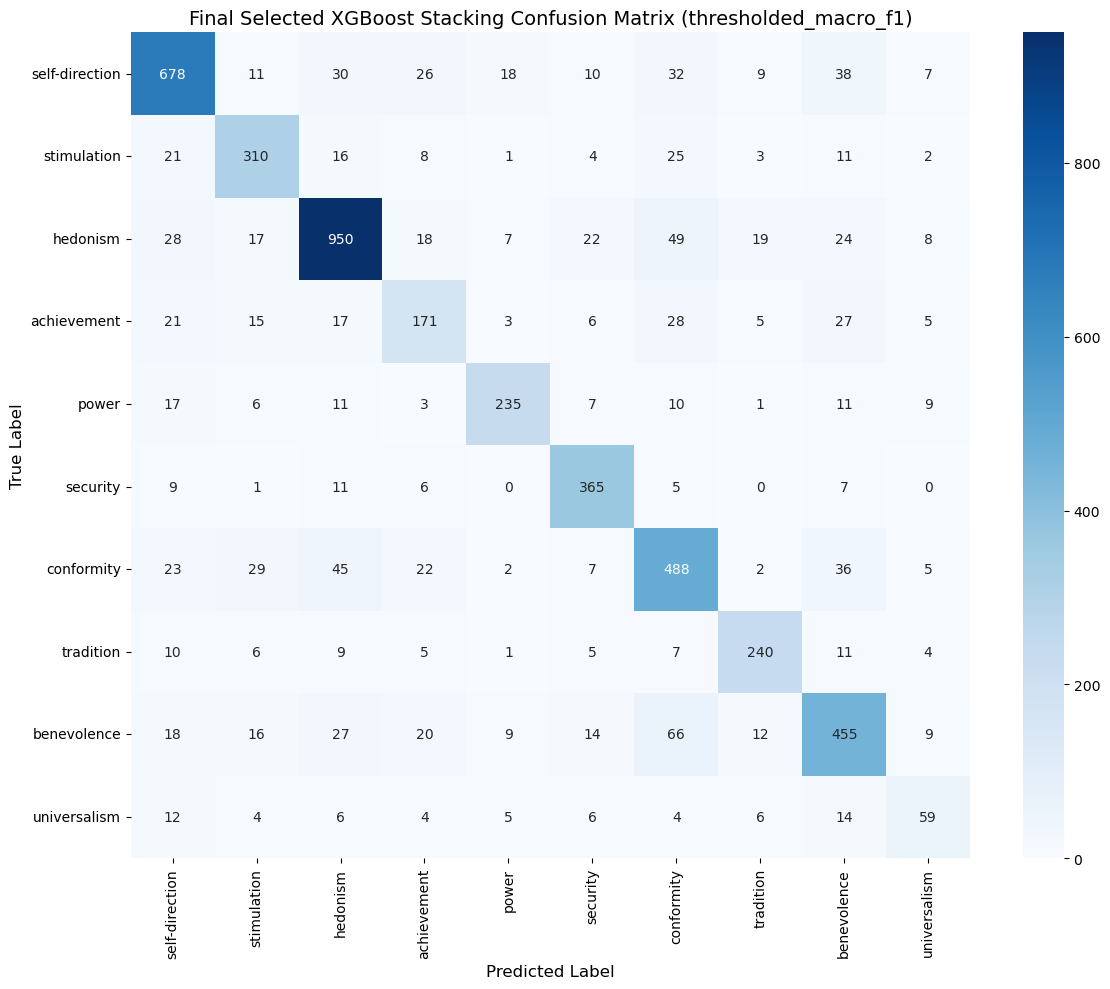

Saved confusion matrix CSV: ./stack_cache_no_retrain/final_selected_xgboost_stacking_confusion_matrix.csv
Saved confusion matrix PNG: ./stack_cache_no_retrain/final_selected_xgboost_stacking_confusion_matrix.png
Saved XGBoost predictions: ./stack_cache_no_retrain/final_selected_xgboost_predictions.csv

FINAL LOGISTIC REGRESSION STACKING — HELD-OUT TEST CLASSIFICATION REPORT
Selected LR config       : LR_C0.05
CV-selected variant      : thresholded_macro_f1
Default argmax           : accuracy=0.7606, macro-F1=0.7287, weighted-F1=0.7604
Thresholded macro-F1     : accuracy=0.7621, macro-F1=0.7297, weighted-F1=0.7618
Final Logistic Regression: accuracy=0.7621, macro-F1=0.7297, weighted-F1=0.7618

Classification report: Final Logistic Regression stacking
                precision    recall  f1-score   support

self-direction     0.7849    0.7986    0.7917       859
   stimulation     0.7650    0.7631    0.7640       401
      hedonism     0.8585    0.8179    0.8377      1142
   achievement 

In [3]:
# FINAL SELECTED XGBOOST STACKING + LOGISTIC REGRESSION REPORT

import seaborn as sns
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)


def cv_selected_macro_f1(row):
    """CV score used for selecting default vs thresholded variants."""
    return max(float(row["cv_macro_f1_default"]), float(row["cv_macro_f1_thresholded"]))


def cv_selected_accuracy(row):
    if row["cv_macro_f1_thresholded"] >= row["cv_macro_f1_default"]:
        return float(row["cv_acc_thresholded"])
    return float(row["cv_acc_default"])


def select_variant_from_cv(row):
    use_thresholds = row["cv_macro_f1_thresholded"] >= row["cv_macro_f1_default"]
    return "thresholded_macro_f1" if use_thresholds else "default_argmax"


def fit_and_evaluate_full_meta(row, X_train_meta, y_train_meta, X_test_meta, y_test, model_display_name):
    config = row["config"]
    thresholds = row["thresholds"]

    model = build_meta_model(config)
    model = fit_meta_model(model, config, X_train_meta, y_train_meta)

    test_proba = normalize_proba(model.predict_proba(X_test_meta))
    pred_default = np.argmax(test_proba, axis=1)
    pred_thresholded = predict_with_thresholds(test_proba, thresholds)

    acc_default = accuracy_score(y_test, pred_default)
    f1_default = f1_score(y_test, pred_default, average="macro")
    weighted_f1_default = f1_score(y_test, pred_default, average="weighted")

    acc_thresholded = accuracy_score(y_test, pred_thresholded)
    f1_thresholded = f1_score(y_test, pred_thresholded, average="macro")
    weighted_f1_thresholded = f1_score(y_test, pred_thresholded, average="weighted")

    final_variant = select_variant_from_cv(row)
    if final_variant == "thresholded_macro_f1":
        y_pred_final = pred_thresholded
    else:
        y_pred_final = pred_default

    final_acc = accuracy_score(y_test, y_pred_final)
    final_macro_f1 = f1_score(y_test, y_pred_final, average="macro")
    final_weighted_f1 = f1_score(y_test, y_pred_final, average="weighted")

    return {
        "model": model,
        "config": config,
        "thresholds": thresholds,
        "test_proba": test_proba,
        "pred_default": pred_default,
        "pred_thresholded": pred_thresholded,
        "y_pred_final": y_pred_final,
        "final_variant": final_variant,
        "acc_default": acc_default,
        "macro_f1_default": f1_default,
        "weighted_f1_default": weighted_f1_default,
        "acc_thresholded": acc_thresholded,
        "macro_f1_thresholded": f1_thresholded,
        "weighted_f1_thresholded": weighted_f1_thresholded,
        "final_acc": final_acc,
        "final_macro_f1": final_macro_f1,
        "final_weighted_f1": final_weighted_f1,
        "display_name": model_display_name,
    }


def save_classification_report_csv(y_true, y_pred, path):
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(n_classes)),
        target_names=your_class_order,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).transpose().to_csv(path)
    return report


def save_confusion_matrix_artifacts(y_true, y_pred, title, csv_path, png_path):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in your_class_order],
        columns=[f"pred_{c}" for c in your_class_order],
    )
    cm_df.to_csv(csv_path)

    print("Confusion matrix:")
    print(cm)

    fig, ax = plt.subplots(figsize=(12, 10))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=your_class_order,
        yticklabels=your_class_order,
        linewidths=0.0,
        ax=ax
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    fig.tight_layout()
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved confusion matrix CSV: {csv_path}")
    print(f"Saved confusion matrix PNG: {png_path}")
    return cm


# Best rows by the same CV-selected metric used for final default/thresholded choice.
best_xgb_row = max(
    [r for r in cv_results if r["kind"] == "xgb"],
    key=lambda r: (cv_selected_macro_f1(r), cv_selected_accuracy(r)),
)
best_lr_row = max(
    [r for r in cv_results if r["kind"] == "lr"],
    key=lambda r: (cv_selected_macro_f1(r), cv_selected_accuracy(r)),
)

print("=" * 90)
print("FINAL SELECTED META-LEARNERS FROM CV")
print("=" * 90)
print(
    f"Selected XGBoost: {best_xgb_row['name']} | "
    f"CV selected variant={select_variant_from_cv(best_xgb_row)} | "
    f"CV macro-F1={cv_selected_macro_f1(best_xgb_row):.4f}"
)
print(
    f"Selected Logistic Regression: {best_lr_row['name']} | "
    f"CV selected variant={select_variant_from_cv(best_lr_row)} | "
    f"CV macro-F1={cv_selected_macro_f1(best_lr_row):.4f}"
)

# Final selected XGBoost
xgb_eval = fit_and_evaluate_full_meta(
    best_xgb_row,
    X_meta,
    y_meta,
    X_test_meta,
    y_test_true,
    model_display_name="XGBoost stacking",
)

xgb_meta_model = xgb_eval["model"]
xgb_thresholds = xgb_eval["thresholds"]
xgb_y_pred_final = xgb_eval["y_pred_final"]
xgb_final_variant = xgb_eval["final_variant"]

print("\n" + "=" * 90)
print("FINAL SELECTED XGBOOST STACKING — HELD-OUT TEST RESULTS")
print("=" * 90)
print(f"Selected XGBoost config : {best_xgb_row['name']}")
print(f"CV-selected variant     : {xgb_final_variant}")
print(f"Default argmax          : accuracy={xgb_eval['acc_default']:.4f}, macro-F1={xgb_eval['macro_f1_default']:.4f}, weighted-F1={xgb_eval['weighted_f1_default']:.4f}")
print(f"Thresholded macro-F1    : accuracy={xgb_eval['acc_thresholded']:.4f}, macro-F1={xgb_eval['macro_f1_thresholded']:.4f}, weighted-F1={xgb_eval['weighted_f1_thresholded']:.4f}")
print(f"Final selected XGBoost  : accuracy={xgb_eval['final_acc']:.4f}, macro-F1={xgb_eval['final_macro_f1']:.4f}, weighted-F1={xgb_eval['final_weighted_f1']:.4f}")

print("\nClassification report: Final selected XGBoost stacking")
print(classification_report(
    y_test_true,
    xgb_y_pred_final,
    labels=list(range(n_classes)),
    target_names=your_class_order,
    digits=4,
    zero_division=0,
))

xgb_report_path = f"{CACHE_DIR}/final_selected_xgboost_stacking_classification_report.csv"
save_classification_report_csv(y_test_true, xgb_y_pred_final, xgb_report_path)
print(f"Saved XGBoost classification report: {xgb_report_path}")

xgb_cm_csv_path = f"{CACHE_DIR}/final_selected_xgboost_stacking_confusion_matrix.csv"
xgb_cm_png_path = f"{CACHE_DIR}/final_selected_xgboost_stacking_confusion_matrix.png"
xgb_cm = save_confusion_matrix_artifacts(
    y_test_true,
    xgb_y_pred_final,
    title=f"Final Selected XGBoost Stacking Confusion Matrix ({xgb_final_variant})",
    csv_path=xgb_cm_csv_path,
    png_path=xgb_cm_png_path,
)

# Save final XGBoost predictions for error analysis.
xgb_predictions_path = f"{CACHE_DIR}/final_selected_xgboost_predictions.csv"
pd.DataFrame({
    "text": X_test_raw,
    "true_label_id": y_test_true,
    "true_label": [idx_to_label[int(i)] for i in y_test_true],
    "pred_label_id": xgb_y_pred_final,
    "pred_label": [idx_to_label[int(i)] for i in xgb_y_pred_final],
    "correct": y_test_true == xgb_y_pred_final,
    "xgb_confidence": np.max(xgb_eval["test_proba"], axis=1),
}).to_csv(xgb_predictions_path, index=False)
print(f"Saved XGBoost predictions: {xgb_predictions_path}")

# Final Logistic Regression
lr_eval = fit_and_evaluate_full_meta(
    best_lr_row,
    X_meta,
    y_meta,
    X_test_meta,
    y_test_true,
    model_display_name="Logistic Regression stacking",
)

lr_meta_model = lr_eval["model"]
lr_y_pred_final = lr_eval["y_pred_final"]
lr_final_variant = lr_eval["final_variant"]

print("\n" + "=" * 90)
print("FINAL LOGISTIC REGRESSION STACKING — HELD-OUT TEST CLASSIFICATION REPORT")
print("=" * 90)
print(f"Selected LR config       : {best_lr_row['name']}")
print(f"CV-selected variant      : {lr_final_variant}")
print(f"Default argmax           : accuracy={lr_eval['acc_default']:.4f}, macro-F1={lr_eval['macro_f1_default']:.4f}, weighted-F1={lr_eval['weighted_f1_default']:.4f}")
print(f"Thresholded macro-F1     : accuracy={lr_eval['acc_thresholded']:.4f}, macro-F1={lr_eval['macro_f1_thresholded']:.4f}, weighted-F1={lr_eval['weighted_f1_thresholded']:.4f}")
print(f"Final Logistic Regression: accuracy={lr_eval['final_acc']:.4f}, macro-F1={lr_eval['final_macro_f1']:.4f}, weighted-F1={lr_eval['final_weighted_f1']:.4f}")

print("\nClassification report: Final Logistic Regression stacking")
print(classification_report(
    y_test_true,
    lr_y_pred_final,
    labels=list(range(n_classes)),
    target_names=your_class_order,
    digits=4,
    zero_division=0,
))

lr_report_path = f"{CACHE_DIR}/final_logistic_regression_stacking_classification_report.csv"
save_classification_report_csv(y_test_true, lr_y_pred_final, lr_report_path)
print(f"Saved Logistic Regression classification report: {lr_report_path}")

# Compatibility variables for the final save-artifacts cell.
best = best_xgb_row
best_config = best_xgb_row["config"]
best_thresholds = xgb_thresholds
final_meta_model = xgb_meta_model
y_pred_final = xgb_y_pred_final
final_variant = xgb_final_variant
acc_default = xgb_eval["acc_default"]
f1_default = xgb_eval["macro_f1_default"]
acc_thr = xgb_eval["acc_thresholded"]
f1_thr = xgb_eval["macro_f1_thresholded"]
final_acc = xgb_eval["final_acc"]
final_f1 = xgb_eval["final_macro_f1"]
final_weighted_f1 = xgb_eval["final_weighted_f1"]

In [4]:
# XGBOOST ABLATION STUDY

BASE_MODEL_SPECS = {
    "gru": {"display": "GRU", "train_key": "train_gru", "test_key": "test_gru"},
    "bert": {"display": "BERT", "train_key": "train_bert", "test_key": "test_bert"},
    "roberta": {"display": "RoBERTa", "train_key": "train_roberta", "test_key": "test_roberta"},
    "svm": {"display": "TF-IDF/SVM", "train_key": "train_svm", "test_key": "test_svm"},
}

# Add or remove tuples here only
XGB_STACKING_COMBINATIONS = [
    ("gru", "bert"),
    ("gru", "roberta"),
    ("gru", "svm"),
    ("bert", "svm"),
    ("roberta", "svm"),
    ("gru", "bert", "svm"),
    ("gru", "roberta", "svm"),
    ("bert", "roberta", "svm"),
    ("gru", "bert", "roberta", "svm"),
]

XGB_ABLATION_CONFIG = best_xgb_row["config"]

print("=" * 90)
print("XGBOOST META-LEARNER ABLATION STUDY")
print("=" * 90)
print(f"XGBoost config reused for all stacking subsets: {best_xgb_row['name']}")


def validate_model_keys(model_keys):
    unknown = [k for k in model_keys if k not in BASE_MODEL_SPECS]
    if unknown:
        raise ValueError(f"Unknown base-model key(s): {unknown}. Available keys: {list(BASE_MODEL_SPECS.keys())}")


def validate_stacking_combinations(combos):
    clean_combos = []
    seen = set()

    for combo in combos:
        combo = tuple(combo)
        validate_model_keys(combo)

        if len(combo) < 2:
            raise ValueError(f"Stacking combination must contain at least two models: {combo}")
        if len(set(combo)) != len(combo):
            raise ValueError(f"Duplicate model key found inside stacking combination: {combo}")

        if combo not in seen:
            clean_combos.append(combo)
            seen.add(combo)

    return clean_combos


def pretty_combo(model_keys):
    return " + ".join(BASE_MODEL_SPECS[k]["display"] for k in model_keys)


def pct(x):
    return round(float(x) * 100.0, 2)


def cross_model_meta_features_dynamic(prob_list, model_prefixes):
    """Cross-model features for any selected subset of base models."""
    prob_stack = np.stack([normalize_proba(p) for p in prob_list], axis=1)
    preds = np.argmax(prob_stack, axis=2)

    mean_prob = prob_stack.mean(axis=1)
    std_prob = prob_stack.std(axis=1)
    min_prob = prob_stack.min(axis=1)
    max_prob = prob_stack.max(axis=1)

    vote_counts = np.zeros((preds.shape[0], n_classes), dtype=float)
    for i in range(preds.shape[0]):
        vote_counts[i] = np.bincount(preds[i], minlength=n_classes)

    agreement_max = vote_counts.max(axis=1, keepdims=True)
    unique_pred_count = np.array([len(np.unique(row)) for row in preds]).reshape(-1, 1)

    pairwise_same_parts = []
    pairwise_names = []
    for i in range(len(model_prefixes)):
        for j in range(i + 1, len(model_prefixes)):
            pairwise_same_parts.append((preds[:, i] == preds[:, j]).astype(float).reshape(-1, 1))
            pairwise_names.append(f"{model_prefixes[i]}_{model_prefixes[j]}_same")

    parts = [
        mean_prob,
        std_prob,
        min_prob,
        max_prob,
        vote_counts,
        agreement_max,
        unique_pred_count,
    ]
    if pairwise_same_parts:
        parts.extend(pairwise_same_parts)

    X = np.hstack(parts)

    names = []
    names += [f"mean_p_{c}" for c in your_class_order]
    names += [f"std_p_{c}" for c in your_class_order]
    names += [f"min_p_{c}" for c in your_class_order]
    names += [f"max_p_{c}" for c in your_class_order]
    names += [f"vote_count_{c}" for c in your_class_order]
    names += ["agreement_max_count", "unique_pred_count"]
    names += pairwise_names

    return X, names


def build_meta_matrix_for_subset(model_keys, split="train"):
    """Build enhanced meta-features for a selected subset of base models."""
    validate_model_keys(model_keys)

    parts = []
    names = []
    probs = []
    prefixes = []

    for key in model_keys:
        prob_key = BASE_MODEL_SPECS[key][f"{split}_key"]
        proba = base_probs[prob_key]
        probs.append(proba)
        prefixes.append(key)

        X_single, single_names = single_model_meta_features(proba, key)
        parts.append(X_single)
        names.extend(single_names)

    X_cross, cross_names = cross_model_meta_features_dynamic(probs, prefixes)
    parts.append(X_cross)
    names.extend(cross_names)

    return np.hstack(parts).astype(np.float32), names


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }


def build_subset_cv_row(model_keys, config, n_splits=5):
    """Run CV and threshold tuning for one selected XGBoost stacking subset."""
    X_subset, _ = build_meta_matrix_for_subset(model_keys, split="train")

    oof_proba = cv_predict_meta_proba(X_subset, y_meta, config, n_splits=n_splits)

    cv_pred_default = np.argmax(oof_proba, axis=1)
    cv_acc_default = accuracy_score(y_meta, cv_pred_default)
    cv_f1_default = f1_score(y_meta, cv_pred_default, average="macro")

    thresholds, cv_f1_thresholded = tune_thresholds_macro_f1(oof_proba, y_meta, n_classes)
    cv_pred_thresholded = predict_with_thresholds(oof_proba, thresholds)
    cv_acc_thresholded = accuracy_score(y_meta, cv_pred_thresholded)

    return {
        "name": config["name"],
        "kind": config["kind"],
        "cv_acc_default": cv_acc_default,
        "cv_macro_f1_default": cv_f1_default,
        "cv_acc_thresholded": cv_acc_thresholded,
        "cv_macro_f1_thresholded": cv_f1_thresholded,
        "thresholds": thresholds,
        "config": config,
        "oof_proba": oof_proba,
    }


def evaluate_xgb_stacking_subset(model_keys, config, n_splits=5):
    X_subset, _ = build_meta_matrix_for_subset(model_keys, split="train")
    X_test_subset, _ = build_meta_matrix_for_subset(model_keys, split="test")

    subset_cv_row = build_subset_cv_row(model_keys, config, n_splits=n_splits)

    subset_eval = fit_and_evaluate_full_meta(
        subset_cv_row,
        X_subset,
        y_meta,
        X_test_subset,
        y_test_true,
        model_display_name=f"XGBoost stacking: {pretty_combo(model_keys)}",
    )

    return {
        "experiment_type": "xgboost_stacking_combination",
        "base_models": pretty_combo(model_keys),
        "n_base_models": len(model_keys),
        "meta_learner": "XGBoost",
        "meta_config": config["name"],
        "cv_selected_variant": subset_eval["final_variant"],
        "cv_accuracy_default": subset_cv_row["cv_acc_default"],
        "cv_macro_f1_default": subset_cv_row["cv_macro_f1_default"],
        "cv_accuracy_thresholded": subset_cv_row["cv_acc_thresholded"],
        "cv_macro_f1_thresholded": subset_cv_row["cv_macro_f1_thresholded"],
        "test_selected_variant": subset_eval["final_variant"],
        "test_accuracy": subset_eval["final_acc"],
        "test_macro_f1": subset_eval["final_macro_f1"],
        "test_weighted_f1": subset_eval["final_weighted_f1"],
        "test_accuracy_%": pct(subset_eval["final_acc"]),
        "test_macro_f1_%": pct(subset_eval["final_macro_f1"]),
        "test_weighted_f1_%": pct(subset_eval["final_weighted_f1"]),
        "test_accuracy_default": subset_eval["acc_default"],
        "test_macro_f1_default": subset_eval["macro_f1_default"],
        "test_weighted_f1_default": subset_eval["weighted_f1_default"],
        "test_accuracy_thresholded": subset_eval["acc_thresholded"],
        "test_macro_f1_thresholded": subset_eval["macro_f1_thresholded"],
        "test_weighted_f1_thresholded": subset_eval["weighted_f1_thresholded"],
    }


# Run XGBoost-only ablation
xgb_ablation_rows = []

xgb_stacking_combos = validate_stacking_combinations(XGB_STACKING_COMBINATIONS)

print("Rows expected:", len(xgb_stacking_combos))
print("  XGBoost stacking rows:", len(xgb_stacking_combos))

for combo in xgb_stacking_combos:
    print(f"\nAblation: {pretty_combo(combo)} | XGBoost {XGB_ABLATION_CONFIG['name']}")
    row = evaluate_xgb_stacking_subset(combo, XGB_ABLATION_CONFIG, n_splits=5)
    xgb_ablation_rows.append(row)
    print(
        f"  CV selected={row['cv_selected_variant']} | "
        f"test_acc={row['test_accuracy']:.4f}, "
        f"test_macroF1={row['test_macro_f1']:.4f}, "
        f"test_weightedF1={row['test_weighted_f1']:.4f}"
    )

xgb_ablation_df = pd.DataFrame(xgb_ablation_rows)
xgb_ablation_df = xgb_ablation_df.sort_values(
    ["test_macro_f1", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)
xgb_ablation_df.insert(0, "rank_by_test_macro_f1", np.arange(1, len(xgb_ablation_df) + 1))

print("\nXGBoost ablation study table:")
display_cols = [
    "rank_by_test_macro_f1",
    "experiment_type",
    "base_models",
    "meta_learner",
    "meta_config",
    "test_selected_variant",
    "test_accuracy_%",
    "test_macro_f1_%",
    "test_weighted_f1_%",
]
print(xgb_ablation_df[display_cols].to_string(index=False))
display(xgb_ablation_df[display_cols])

Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
xgb_ablation_path = f"{CACHE_DIR}/xgboost_ablation_stacking_combinations.csv"
xgb_ablation_df.to_csv(xgb_ablation_path, index=False)
print(f"Saved XGBoost ablation table: {xgb_ablation_path}")

# SAVE FINAL XGBOOST STACKING ARTIFACTS

Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

xgb_model_path = f"{CACHE_DIR}/human_values_no_retrain_final_selected_xgboost_{best_xgb_row['name']}.pkl"
xgb_threshold_path = f"{CACHE_DIR}/optimal_thresholds_final_selected_xgboost_{best_xgb_row['name']}.pkl"
lr_model_path = f"{CACHE_DIR}/human_values_no_retrain_final_logistic_regression_{best_lr_row['name']}.pkl"
summary_path = f"{CACHE_DIR}/final_xgboost_stacking_summary.json"

joblib.dump(xgb_meta_model, xgb_model_path)
joblib.dump(xgb_thresholds, xgb_threshold_path)
joblib.dump(lr_meta_model, lr_model_path)

summary = {
    "final_selected_meta_learner": "XGBoost",
    "xgboost_config": best_xgb_row["name"],
    "xgboost_final_variant": xgb_final_variant,
    "xgboost_test_accuracy_default": float(xgb_eval["acc_default"]),
    "xgboost_test_macro_f1_default": float(xgb_eval["macro_f1_default"]),
    "xgboost_test_weighted_f1_default": float(xgb_eval["weighted_f1_default"]),
    "xgboost_test_accuracy_thresholded": float(xgb_eval["acc_thresholded"]),
    "xgboost_test_macro_f1_thresholded": float(xgb_eval["macro_f1_thresholded"]),
    "xgboost_test_weighted_f1_thresholded": float(xgb_eval["weighted_f1_thresholded"]),
    "xgboost_final_test_accuracy": float(xgb_eval["final_acc"]),
    "xgboost_final_test_macro_f1": float(xgb_eval["final_macro_f1"]),
    "xgboost_final_test_weighted_f1": float(xgb_eval["final_weighted_f1"]),
    "logistic_regression_config": best_lr_row["name"],
    "logistic_regression_final_variant": lr_final_variant,
    "logistic_regression_final_test_accuracy": float(lr_eval["final_acc"]),
    "logistic_regression_final_test_macro_f1": float(lr_eval["final_macro_f1"]),
    "logistic_regression_final_test_weighted_f1": float(lr_eval["final_weighted_f1"]),
    "class_order": your_class_order,
    "xgboost_thresholds": [float(x) for x in xgb_thresholds],
    "note": "Base models were not retrained. Meta-features were generated from saved final base models. Final default-vs-thresholded choice used CV metrics only.",
    "saved_files": {
        "xgboost_model": xgb_model_path,
        "xgboost_thresholds": xgb_threshold_path,
        "logistic_regression_model": lr_model_path,
        "xgboost_classification_report": xgb_report_path,
        "xgboost_confusion_matrix_csv": xgb_cm_csv_path,
        "xgboost_confusion_matrix_png": xgb_cm_png_path,
        "xgboost_predictions": xgb_predictions_path,
        "logistic_regression_classification_report": lr_report_path,
        "xgboost_ablation_table": xgb_ablation_path,
        "meta_cv_leaderboard": f"{CACHE_DIR}/meta_cv_leaderboard.csv",
        "feature_names": f"{CACHE_DIR}/enhanced_meta_feature_names.json",
    },
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved final artifacts:")
print(f"  Final XGBoost meta-model:          {xgb_model_path}")
print(f"  Final XGBoost thresholds:          {xgb_threshold_path}")
print(f"  Final Logistic Regression model:   {lr_model_path}")
print(f"  Final summary JSON:                {summary_path}")
print(f"  XGBoost classification report:     {xgb_report_path}")
print(f"  XGBoost confusion matrix CSV:      {xgb_cm_csv_path}")
print(f"  XGBoost confusion matrix PNG:      {xgb_cm_png_path}")
print(f"  XGBoost ablation table:            {xgb_ablation_path}")
print(f"  Logistic Regression report:        {lr_report_path}")

# XGBoost feature importance for interpretation.
if hasattr(xgb_meta_model, "feature_importances_"):
    imp = pd.DataFrame({
        "feature": meta_feature_names,
        "importance": xgb_meta_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    imp_path = f"{CACHE_DIR}/final_selected_xgboost_feature_importance.csv"
    imp.to_csv(imp_path, index=False)
    print(f"  XGBoost feature importance:        {imp_path}")
    display(imp.head(30))

print("\nFinal XGBoost stacking script complete.")

XGBOOST META-LEARNER ABLATION STUDY
XGBoost config reused for all stacking subsets: XGB_d2_lr003_n200
Rows expected: 9
  XGBoost stacking rows: 9

Ablation: GRU + BERT | XGBoost XGB_d2_lr003_n200
  XGB_d2_lr003_n200 | fold 1/5 done
  XGB_d2_lr003_n200 | fold 2/5 done
  XGB_d2_lr003_n200 | fold 3/5 done
  XGB_d2_lr003_n200 | fold 4/5 done
  XGB_d2_lr003_n200 | fold 5/5 done
  CV selected=thresholded_macro_f1 | test_acc=0.7646, test_macroF1=0.7360, test_weightedF1=0.7646

Ablation: GRU + RoBERTa | XGBoost XGB_d2_lr003_n200
  XGB_d2_lr003_n200 | fold 1/5 done
  XGB_d2_lr003_n200 | fold 2/5 done
  XGB_d2_lr003_n200 | fold 3/5 done
  XGB_d2_lr003_n200 | fold 4/5 done
  XGB_d2_lr003_n200 | fold 5/5 done
  CV selected=thresholded_macro_f1 | test_acc=0.7594, test_macroF1=0.7300, test_weightedF1=0.7594

Ablation: GRU + TF-IDF/SVM | XGBoost XGB_d2_lr003_n200
  XGB_d2_lr003_n200 | fold 1/5 done
  XGB_d2_lr003_n200 | fold 2/5 done
  XGB_d2_lr003_n200 | fold 3/5 done
  XGB_d2_lr003_n200 | fold 4/5 

,rank_by_test_macro_f1,experiment_type,base_models,meta_learner,meta_config,test_selected_variant,test_accuracy_%,test_macro_f1_%,test_weighted_f1_%
0,1,xgboost_stacking_combination,GRU + BERT + RoBERTa + TF-IDF/SVM,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,76.91,73.87,76.87
1,2,xgboost_stacking_combination,BERT + RoBERTa + TF-IDF/SVM,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,76.70,73.63,76.68
2,3,xgboost_stacking_combination,GRU + BERT,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,76.46,73.60,76.46
3,4,xgboost_stacking_combination,GRU + BERT + TF-IDF/SVM,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,76.19,73.39,76.21
4,5,xgboost_stacking_combination,BERT + TF-IDF/SVM,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,76.23,73.25,76.28
5,6,xgboost_stacking_combination,GRU + RoBERTa,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,75.94,73.00,75.94
6,7,xgboost_stacking_combination,RoBERTa + TF-IDF/SVM,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,75.80,72.99,75.91
7,8,xgboost_stacking_combination,GRU + RoBERTa + TF-IDF/SVM,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,75.71,72.59,75.77
8,9,xgboost_stacking_combination,GRU + TF-IDF/SVM,XGBoost,XGB_d2_lr003_n200,thresholded_macro_f1,68.58,64.85,68.59


Saved XGBoost ablation table: ./stack_cache_no_retrain/xgboost_ablation_stacking_combinations.csv
Saved final artifacts:
  Final XGBoost meta-model:          ./stack_cache_no_retrain/human_values_no_retrain_final_selected_xgboost_XGB_d2_lr003_n200.pkl
  Final XGBoost thresholds:          ./stack_cache_no_retrain/optimal_thresholds_final_selected_xgboost_XGB_d2_lr003_n200.pkl
  Final Logistic Regression model:   ./stack_cache_no_retrain/human_values_no_retrain_final_logistic_regression_LR_C0.05.pkl
  Final summary JSON:                ./stack_cache_no_retrain/final_xgboost_stacking_summary.json
  XGBoost classification report:     ./stack_cache_no_retrain/final_selected_xgboost_stacking_classification_report.csv
  XGBoost confusion matrix CSV:      ./stack_cache_no_retrain/final_selected_xgboost_stacking_confusion_matrix.csv
  XGBoost confusion matrix PNG:      ./stack_cache_no_retrain/final_selected_xgboost_stacking_confusion_matrix.png
  XGBoost ablation table:            ./stack_cach

,feature,importance
59,bert_top1_is_universalism,0.165655
57,bert_top1_is_tradition,0.154267
51,bert_top1_is_stimulation,0.127099
56,bert_top1_is_conformity,0.064337
52,bert_top1_is_hedonism,0.058493
55,bert_top1_is_security,0.057847
58,bert_top1_is_benevolence,0.045880
54,bert_top1_is_power,0.038300
92,roberta_top1_is_tradition,0.037619
50,bert_top1_is_self-direction,0.018719



Final XGBoost stacking script complete.
